In [19]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt

### Combining Novel Datasets

Here we combine and clean up the data sets by adding the Hardcover descriptions and tags, and the Hugo and Locus award finalist information, to the novel dataset from ISFDB.

In [60]:
isfdb_books = pd.read_csv('data/isfdb_novels_06-06.csv', delimiter=',')
hugo_finalists = pd.read_csv('data/hugo_nominees.csv', delimiter=',', header=0)
locus_finalists = pd.read_csv('data/locus_nominees.csv', delimiter=',', header=0, encoding='utf-8')
hardcover_data = pd.read_csv('data/hardcover_bookdetails.csv', delimiter='\t')


In [21]:
isfdb_books.head(3)

,title_id,title,type,author,release_year,release_date,author_age_at_release,author_birthplace,synopsis,tags,isbn,first_publisher
0,1,The Warrior Who Carried Life,NOVEL,Geoff Ryman,1985,1985-05-00,34.0,Canada,<b>From the back cover of the Bantam paperback...,"bsfa award for best novel finalist, fantasy, f...",0044407777,Unwin Paperbacks
1,4,The Winds of Altair,NOVEL,Ben Bova,1973,1973-03-00,41.0,"Philadelphia, Pennsylvania, USA",NaN,"science fiction, young-adult sf",0727817760,Severn House
2,6,Empire Builders,NOVEL,Ben Bova,1993,1993-09-00,61.0,"Philadelphia, Pennsylvania, USA",NaN,science fiction,0812511654,Tor


In [22]:
hardcover_data.head(3)

,batch_num,isbn,title,description,tags
0,0,0553408534,Conquerors' Pride,"Timothy Zahn, Hugo Award-winning author of The...","[{'Fiction': 1}, {'Science Fiction': 1}, {'Fan..."
1,0,0671655981,Spinneret,"Set in the crowded galaxy of the future, Earth...","[{'Fiction': 1}, {'Science fiction': 1}]"
2,0,0553564927,The Last Command,The conclusion to the epic adventure begun in ...,"[{'Science Fiction': 3}, {'Fantasy': 2}, {'Fic..."


In [23]:
hugo_finalists.head(3)

,title,author,year
0,The Demolished Man,Alfred Bester,1953
1,They'd Rather Be Right(akaThe Forever Machine),Mark Clifton&Frank Riley,1955
2,Double Star,Robert A. Heinlein,1956


In [24]:
locus_finalists.head(3)

,title,author,year
0,Ringworld,Larry Niven,1971
1,Tower of Glass,Robert Silverberg,1971
2,The Year of the Quiet Sun,Wilson Tucker,1971


First combine ISFDB and Hardcover books, using ISBN code to combine.

<Axes: >

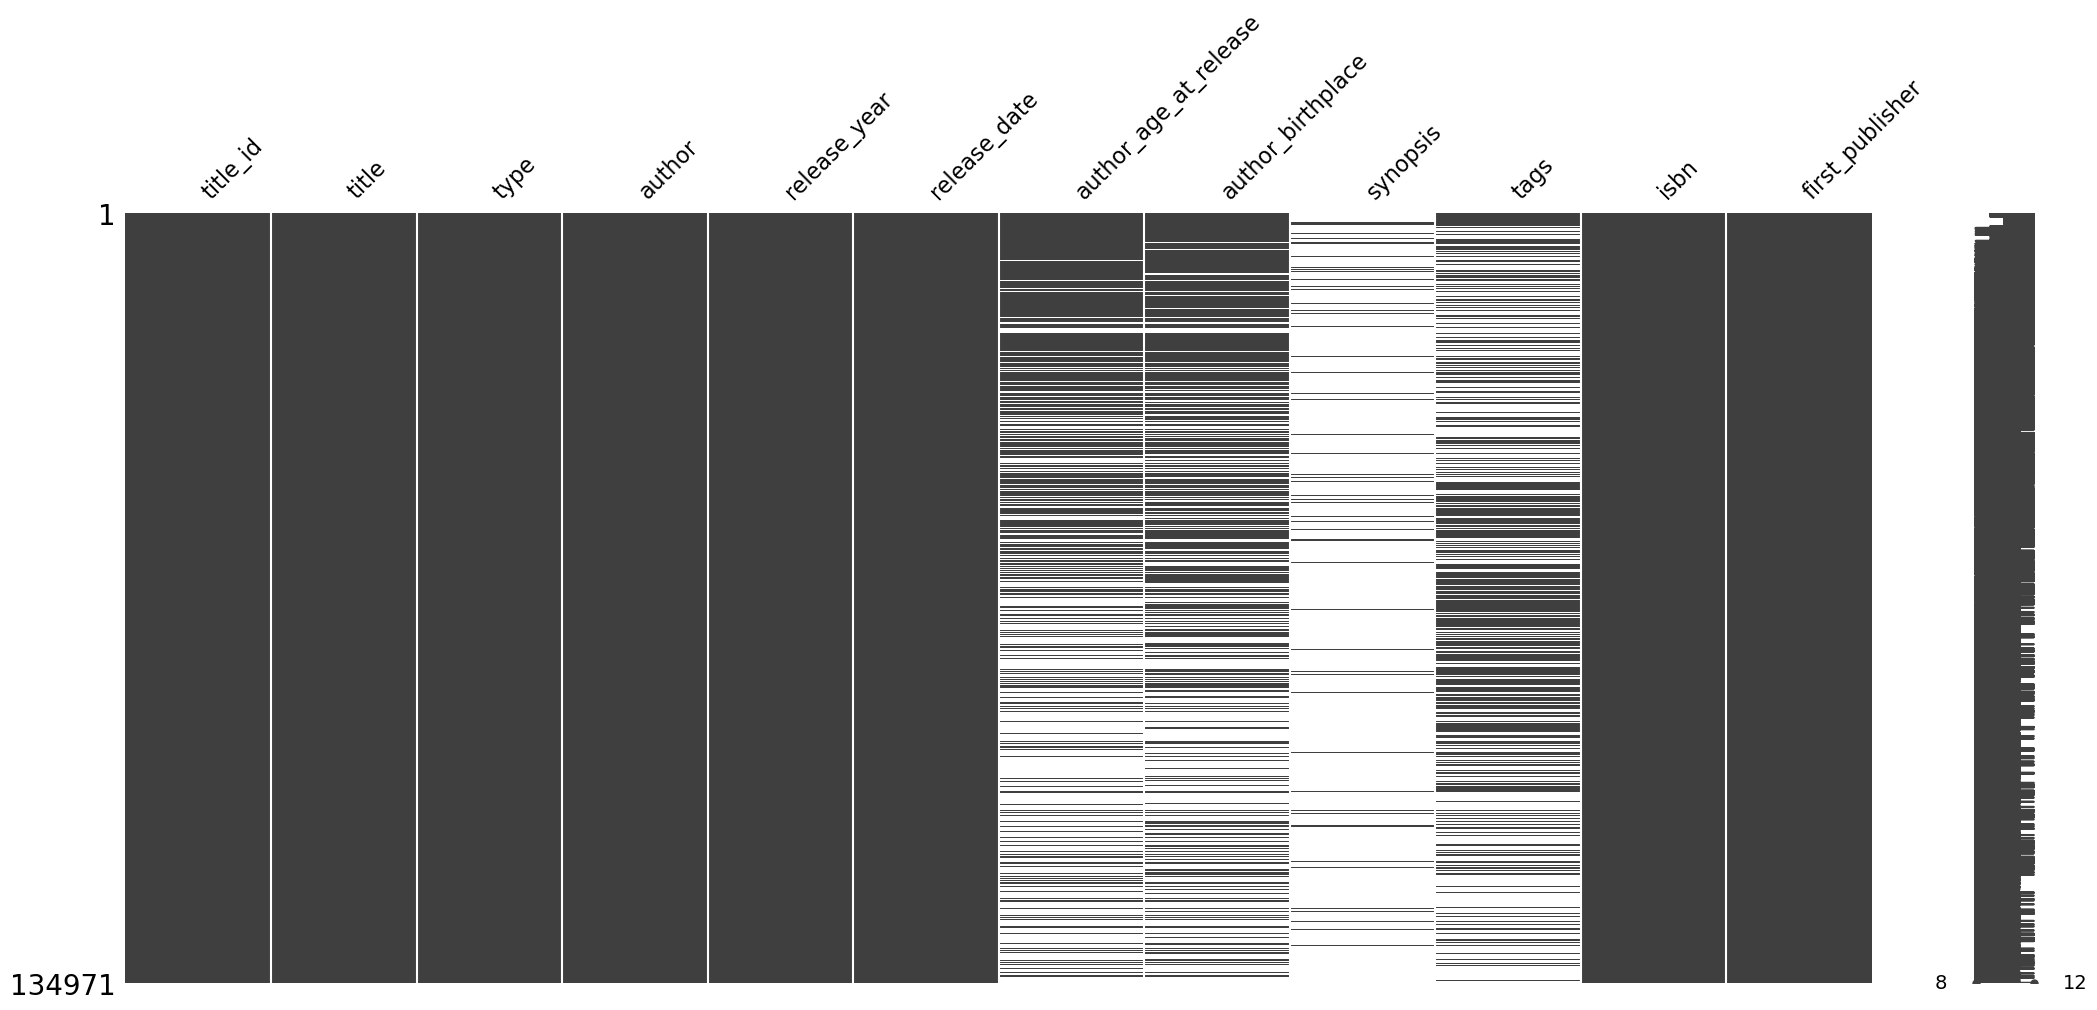

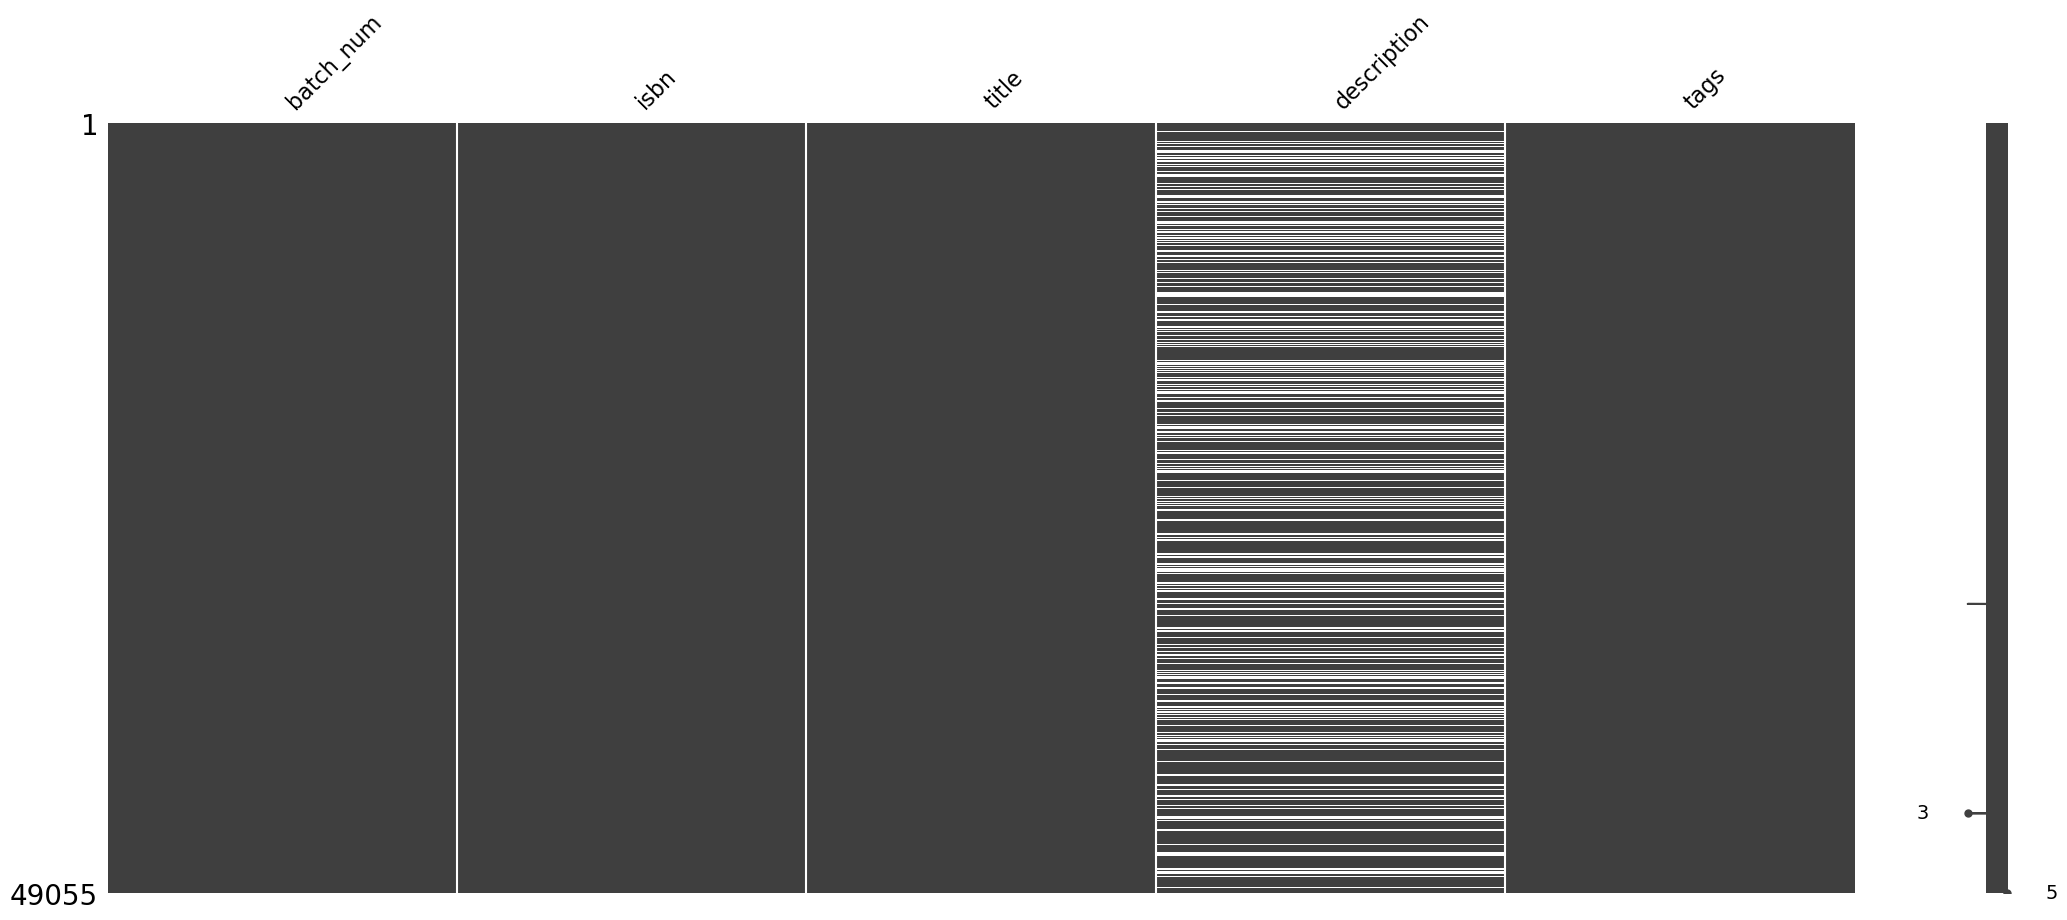

In [25]:
msno.matrix(isfdb_books)
msno.matrix(hardcover_data)


In [26]:
isfdb_hardcover = pd.merge(isfdb_books, hardcover_data, on='isbn', how="left")

In [27]:
isfdb_hardcover.head(3)

,title_id,title_x,type,author,release_year,release_date,author_age_at_release,author_birthplace,synopsis,tags_x,isbn,first_publisher,batch_num,title_y,description,tags_y
0,1,The Warrior Who Carried Life,NOVEL,Geoff Ryman,1985,1985-05-00,34.0,Canada,<b>From the back cover of the Bantam paperback...,"bsfa award for best novel finalist, fantasy, f...",0044407777,Unwin Paperbacks,NaN,NaN,NaN,NaN
1,4,The Winds of Altair,NOVEL,Ben Bova,1973,1973-03-00,41.0,"Philadelphia, Pennsylvania, USA",NaN,"science fiction, young-adult sf",0727817760,Severn House,NaN,NaN,NaN,NaN
2,6,Empire Builders,NOVEL,Ben Bova,1993,1993-09-00,61.0,"Philadelphia, Pennsylvania, USA",NaN,science fiction,0812511654,Tor,0.0,Empire Builders,NaN,"[{'Fantasy': 1}, {'Adventure': 1}, {'Fiction':..."


In [28]:
isfdb_hardcover = isfdb_hardcover.drop(['title_y', 'batch_num', 'type'], axis=1) # drop extra or useless cols


In [29]:
isfdb_hardcover[~(isfdb_hardcover['synopsis'].isna() | isfdb_hardcover['description'].isna())][['synopsis', 'description']]

,synopsis,description
6,"""Keith Stoner, ex-astronaut turned physicist, ...",Ex-astronaut turned physicist Keith Stoner kno...
7,Picks up the series 274 years after <i>TFoH</i...,Two hundred and seventy-four years after the f...
13,A long era of peace and prosperity in the inte...,"Timothy Zahn, Hugo Award-winning author of The..."
18,<b>From the back cover of the Baen second prin...,Death-row inmates are used for a lethal mining...
24,"""Seduced by the lure of power, Jonny Moreau, a...","He was a New Kind of Soldier, Created for a Ne..."
...,...,...
135237,"""The world is ending, and down-and-out sadist ...",A New York Times Book Review Editors' Choice A...
135252,"The newly minted <i>EAS Dauntless</i>, which i...","In the year 2199, Earth Alliance President Tho..."
135253,"<br>&#9679; ""Captain Noah Fletcher and the cre...",Captain Noah Fletcher and the crew of the Daun...
135390,"""An impulsive word can start a war.\nA timely ...",An impulsive word can start a war.\nA timely w...


In [30]:
# combine ISFDB synopsis and Hardcover description into one col; if both exist, take the longer one

isfdb_hardcover['book_synopsis'] = isfdb_hardcover['synopsis'].combine(isfdb_hardcover['description'], lambda a, b:(
    a if pd.isna(b) else b if pd.isna(a) else a if len(a) > len(b) else b 
))

In [31]:
# drop extra columns 
isfdb_hardcover = isfdb_hardcover.drop(['synopsis', 'description'], axis=1) # drop extra or useless cols

In [32]:
# combine book tags. Hardcover also gives the # of times a tag has been applied,
# remove these for now but perhaps we can go back and get them

import ast

def combine_tags(a, b):
    if (pd.isna(a) and pd.isna(b)):
        return np.nan
    elif pd.isna(b):
        return a.split(', ')
    b_dict = ast.literal_eval(b)
    b_keys =  [list(item.keys())[0] for item in b_dict]
    if pd.isna(a):
        return b_keys
    else:
        return a.split(', ') + b_keys


isfdb_hardcover['tags'] = isfdb_hardcover['tags_x'].combine(isfdb_hardcover['tags_y'], combine_tags)

In [33]:
isfdb_hardcover[['tags', 'tags_x', 'tags_y']].head(3)

,tags,tags_x,tags_y
0,"[bsfa award for best novel finalist, fantasy, ...","bsfa award for best novel finalist, fantasy, f...",NaN
1,"[science fiction, young-adult sf]","science fiction, young-adult sf",NaN
2,"[science fiction, Fantasy, Adventure, Fiction,...",science fiction,"[{'Fantasy': 1}, {'Adventure': 1}, {'Fiction':..."


In [34]:
isfdb_hardcover = isfdb_hardcover.drop(['tags_x', 'tags_y'], axis=1) # drop extra or useless cols

In [35]:
isfdb_hardcover['title'] = isfdb_hardcover['title_x']
isfdb_hardcover = isfdb_hardcover.drop(['title_x'], axis=1) # drop extra or useless cols

<Axes: >

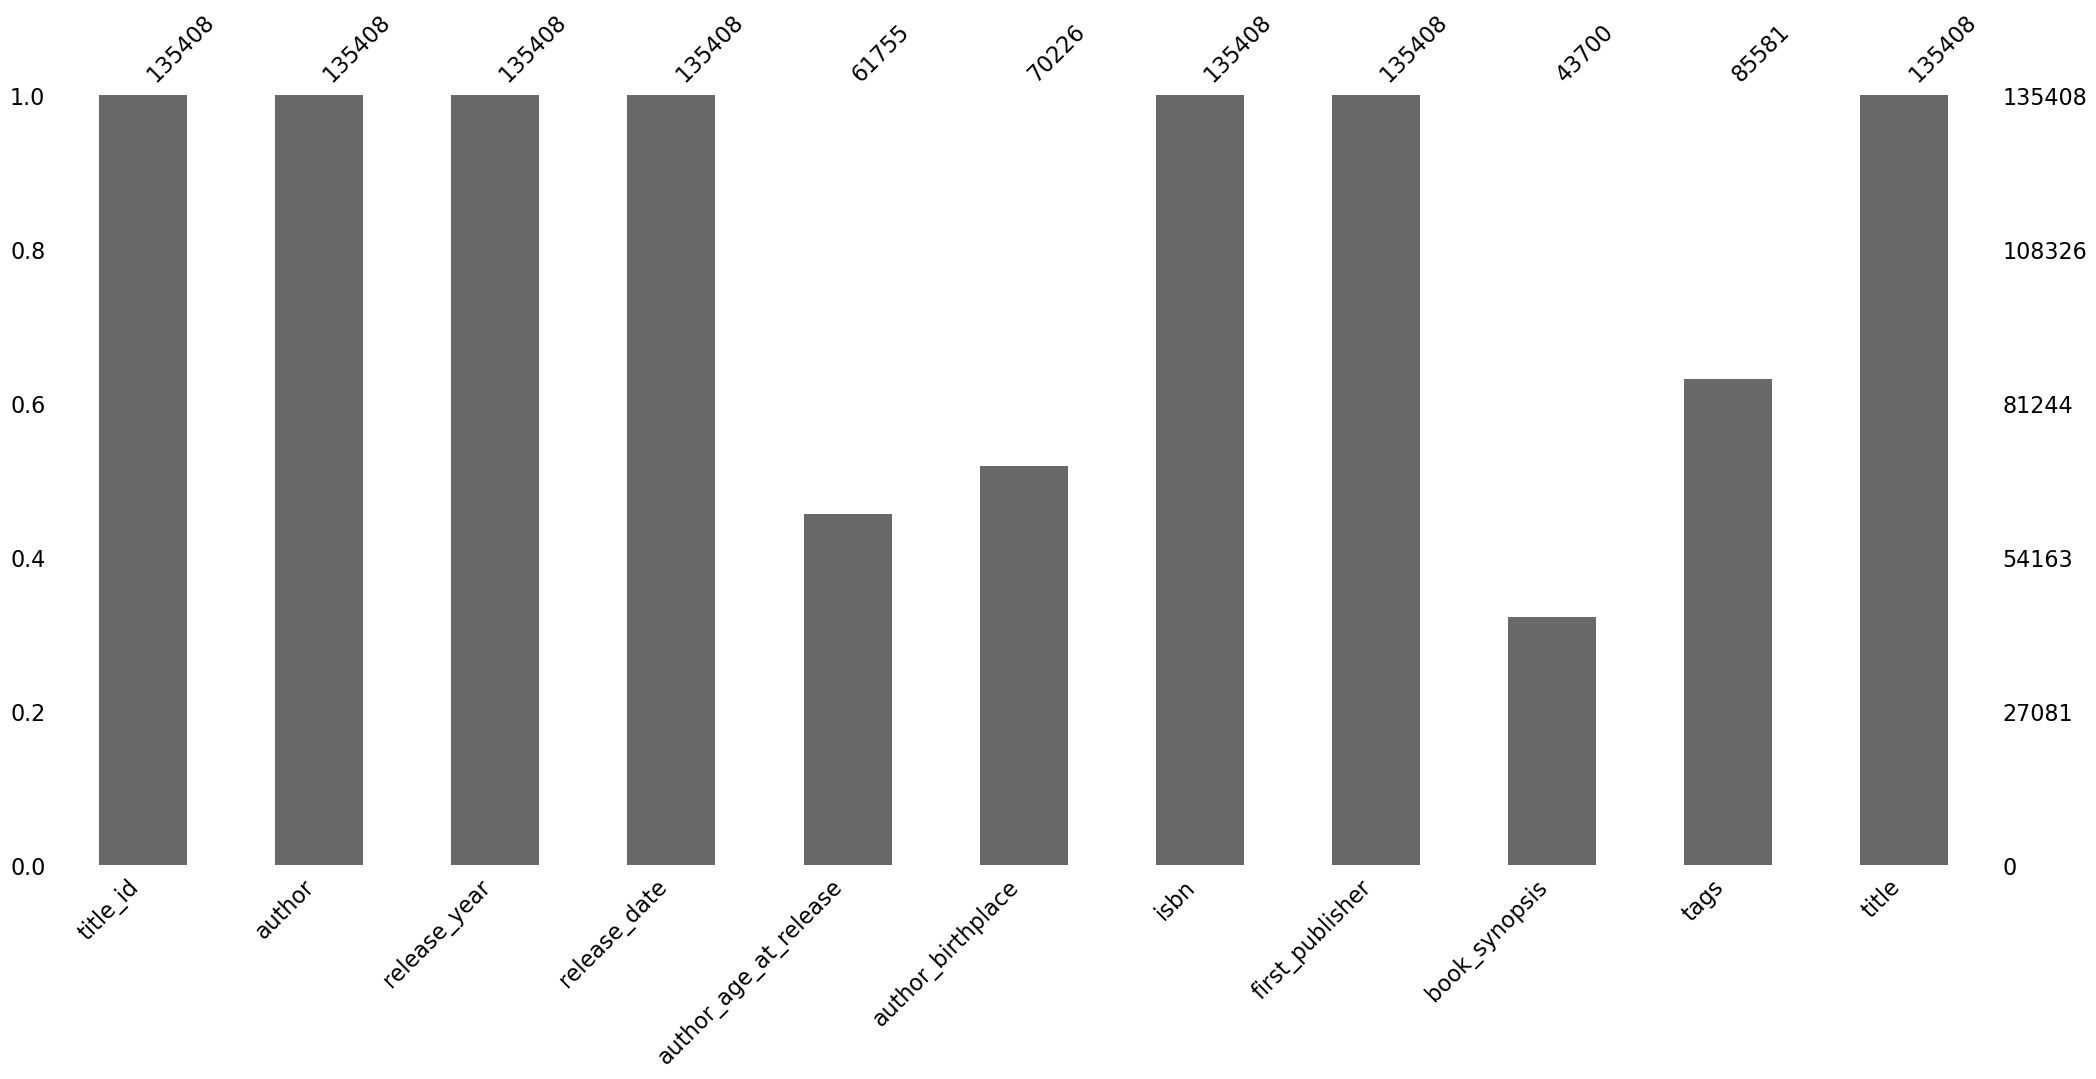

In [36]:
msno.bar(isfdb_hardcover)

### Adding in a column to identify books that won an award and those that did not 

In [61]:

combined_awards = pd.merge(hugo_finalists, locus_finalists, on='title', how='outer')

In [62]:
combined_awards

,title,author_x,year_x,author_y,year_y
0,A Comedy of Justice,NaN,NaN,Robert A. Heinlein,1985.0
1,A Novel with Three Codas,John Scalzi,2013.0,NaN,NaN
2,In the Cities of Coin and Spice,NaN,NaN,Catherynne M. Valente,2008.0
3,The Confusion; The System of the World,NaN,NaN,Neal Stephenson,2005.0
4,The Last Book of Earthsea,NaN,NaN,Ursula K. Le Guin,1991.0
...,...,...,...,...,...
2220,“The Tactics of Mistake”,NaN,NaN,Gordon R. Dickson,1971.0
2221,“Time Killer” (expanded asImmortality,Inc),1959.0,NaN,NaN
2222,“We Have Fed Our Sea” (book titleThe Enemy Stars),Poul Anderson,1959.0,NaN,NaN
2223,�gypt,NaN,NaN,John Crowley,1988.0


In [68]:
unidentified = 0
for title in hugo_finalists['title']:
    if title not in isfdb_hardcover['title'].values:
        print(title)
        unidentified += 1
print("unidentified books:", unidentified, " out of ", len(hugo_finalists))

They'd Rather Be Right(akaThe Forever Machine)
“Call Him Dead”
Have Space Suit -- Will Travel
“Time Killer” (expanded asImmortality
“We Have Fed Our Sea” (book titleThe Enemy Stars)
“Dorsai!” (book titleThe Genetic General)
“The Pirates of Ersatz” (book titleThe Pirates of Zan)
“That Sweet Little Old Lady” (book titleBrain Twister)
“The Fisherman” (book titleTime Is the Simplest Thing)
“Sense of Obligation” (book titlePlanet of the Damned)
Sylva
“Here Gather the Stars” (book titleWay Station)
“Dune World”
“...And Call Me Conrad” (expanded asThis Immortal)
Slaughterhouse-Five
“Star Light”
The Dispossessed
Flow My Tears
The Inverted World
The Mote In God's Eye
“Inferno”
Little
Beggars In Spain
Beggars and Choosers
The Terminal Experiment(serial title “Hobson's Choice“)
To Say Nothing of the Dog
Harry Potter and the Prisoner of Azkaban
Harry Potter and the Goblet of Fire
Eifelheim
His Majesty's Dragon
WWW: Wake
Blackout/All Clear
 A Novel with Three Codas
The Wheel of Time
The Three-Body 

some issues with encoding of special characters showing up as question marks, as well as books with slightly different formatting... i also haven't implemented checking the titles.